In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [229]:
df = pd.read_csv("../dataset/energydata_complete.csv")

# Drop ID column
df.drop("Home ID", axis=1, inplace=True)
df.drop("energy_per_person", axis=1, inplace=True, errors="ignore")
df.head()

,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [230]:
df.shape

(100000, 7)

In [231]:
df.columns

Index(['Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date',
       'Outdoor Temperature (°C)', 'Season', 'Household Size'],
      dtype='object')

In [232]:
df.info

<bound method DataFrame.info of          Appliance Type  Energy Consumption (kWh)   Time        Date  \
0                Fridge                      0.20  21:12  2023-12-02   
1                  Oven                      0.23  20:11  2023-08-06   
2            Dishwasher                      0.32  06:39  2023-11-21   
3                Heater                      3.92  21:56  2023-01-21   
4             Microwave                      0.44  04:31  2023-08-26   
...                 ...                       ...    ...         ...   
99995         Microwave                      0.42  09:56  2023-09-28   
99996          Computer                      0.71  12:48  2023-05-27   
99997        Dishwasher                      0.25  05:45  2023-02-18   
99998  Air Conditioning                      2.69  12:39  2023-04-20   
99999            Fridge                      0.37  18:46  2023-02-27   

       Outdoor Temperature (°C)  Season  Household Size  
0                          -1.0    Fall      

In [233]:
df.describe()

,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,100000.000000,100000.000000,100000.000000
mean,1.499952,14.950135,3.001770
std,1.181176,14.438755,1.417077
min,0.100000,-10.000000,1.000000
25%,0.590000,2.400000,2.000000
50%,1.230000,14.900000,3.000000
75%,1.870000,27.400000,4.000000
max,5.000000,40.000000,5.000000


In [234]:
df.isnull().sum()

Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

In [235]:
df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])

In [236]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month

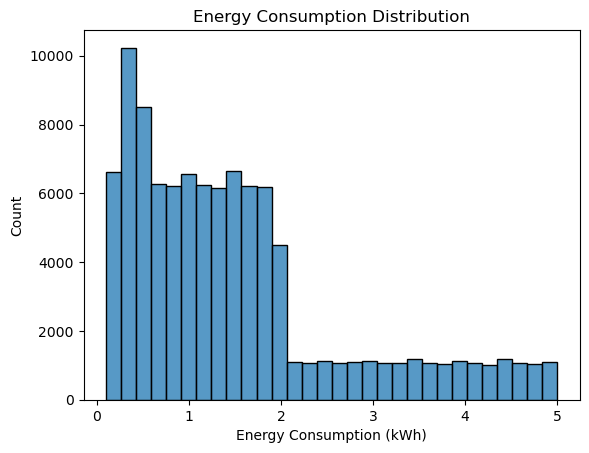

In [237]:
sns.histplot(df['Energy Consumption (kWh)'], bins=30)
plt.title("Energy Consumption Distribution")
plt.show()

<Axes: xlabel='Outdoor Temperature (°C)', ylabel='Energy Consumption (kWh)'>

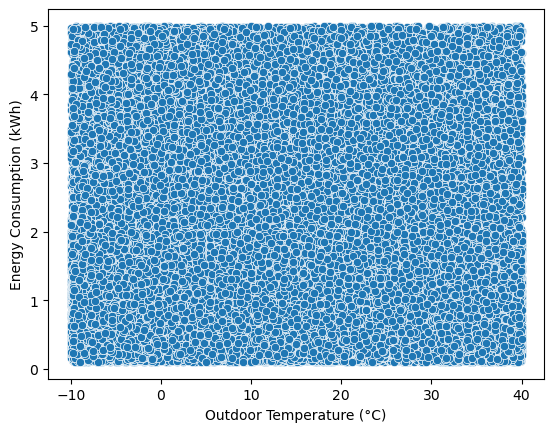

In [238]:
sns.scatterplot(x='Outdoor Temperature (°C)', 
                y='Energy Consumption (kWh)', data=df)

<Axes: xlabel='Season', ylabel='Energy Consumption (kWh)'>

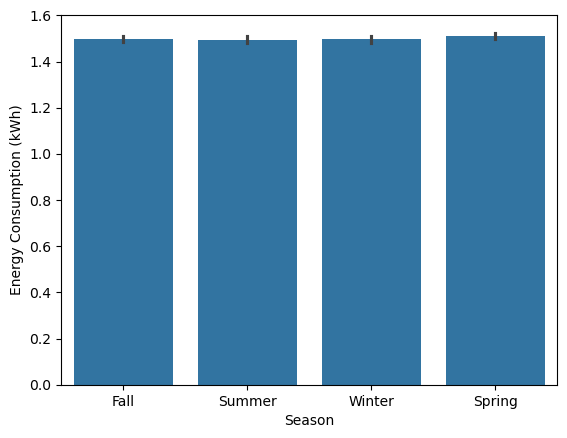

In [239]:
sns.barplot(x='Season', y='Energy Consumption (kWh)', data=df)

<Axes: xlabel='hour', ylabel='Energy Consumption (kWh)'>

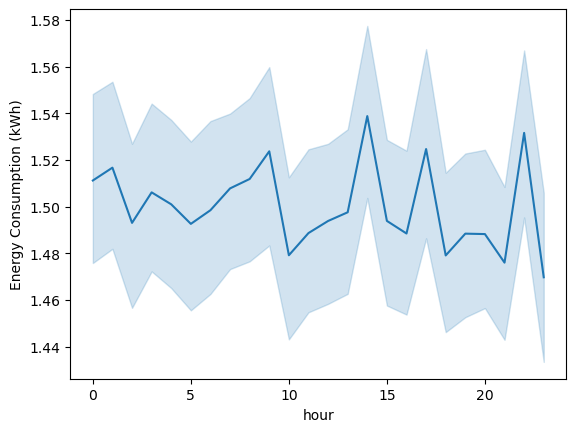

In [240]:
sns.lineplot(x='hour', y='Energy Consumption (kWh)', data=df)

In [241]:
df['peak_hour'] = df['hour'].apply(lambda x: 1 if 17 <= x <= 22 else 0)

In [242]:
le = LabelEncoder()

df['Appliance Type'] = le.fit_transform(df['Appliance Type'])
df['Season'] = le.fit_transform(df['Season'])

In [243]:
df.drop(['Date','Time','datetime'], axis=1, inplace=True)

X = df.drop('Energy Consumption (kWh)', axis=1)
y = df['Energy Consumption (kWh)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [244]:
# Split scaled features
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [245]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [246]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [247]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    random_state=42
)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [248]:
!pip install xgboost

In [249]:
from xgboost import XGBRegressor

In [250]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [251]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [252]:
results_all = pd.DataFrame({

"Model": [
"Linear Regression",
"Decision Tree",
"Random Forest",
"XGBoost"
],

"MAE":[
evaluate(y_test,pred_lr)[0],
evaluate(y_test,pred_dt)[0],
evaluate(y_test,pred_rf)[0],
evaluate(y_test,pred_xgb)[0]
],

"RMSE":[
evaluate(y_test,pred_lr)[1],
evaluate(y_test,pred_dt)[1],
evaluate(y_test,pred_rf)[1],
evaluate(y_test,pred_xgb)[1]
],

"R2":[
evaluate(y_test,pred_lr)[2],
evaluate(y_test,pred_dt)[2],
evaluate(y_test,pred_rf)[2],
evaluate(y_test,pred_xgb)[2]
]

})

results_all

,Model,MAE,RMSE,R2
0,Linear Regression,0.873523,1.123817,0.102074
1,Decision Tree,0.476404,0.584717,0.756925
2,Random Forest,0.476154,0.584314,0.757260
3,XGBoost,0.477114,0.586562,0.755389


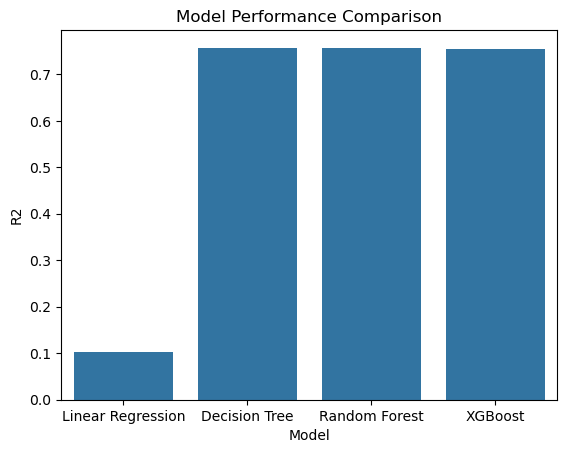

In [253]:
sns.barplot(x="Model", y="R2", data=results_all)

plt.title("Model Performance Comparison")

plt.show()

In [254]:
df.columns


Index(['Appliance Type', 'Energy Consumption (kWh)',
       'Outdoor Temperature (°C)', 'Season', 'Household Size', 'hour', 'month',
       'peak_hour'],
      dtype='object')

In [255]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,Appliance Type,0.992298
1,Outdoor Temperature (°C),0.003789
4,hour,0.001744
5,month,0.001105
3,Household Size,0.000730
2,Season,0.000247
6,peak_hour,0.000088


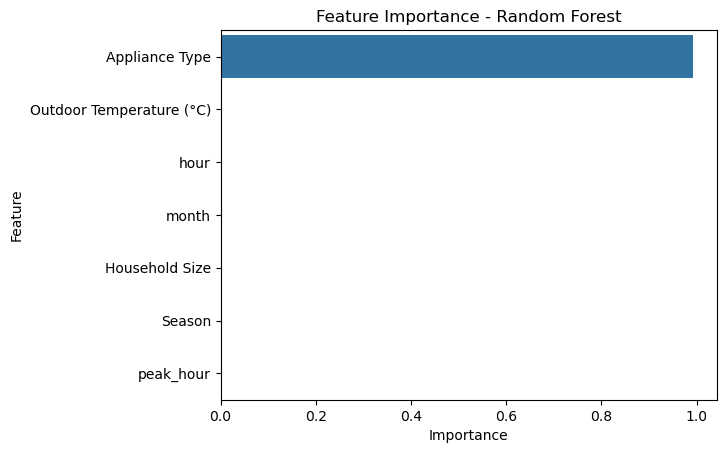

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.show()